In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [13]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
import umap
import matplotlib.pyplot as plt

In [7]:
# Load CSV into a DataFrame
df = pd.read_csv("../../data/lncHUB2/umap_results_df.csv")
# Rename Unnamed: 0 -> gene
df = df.rename(columns={"Unnamed: 0": "gene"})
print(df.head())

          gene         x         y
0     A1BG-AS1  5.146417  1.982774
1      A2M-AS1  3.186969  2.305194
2    A2ML1-AS1 -4.484245  4.662058
3    A2ML1-AS2 -5.818414  4.214316
4  AADACL2-AS1 -4.124925  5.310025


In [26]:
import numpy as np
from scipy.spatial.distance import cdist

# --- Gene sets ---
known_genes = ["DLEU1", "DLEU2", "MIAT", "NEAT1", "PVT1"]

test_genes = ["FIRRE", "MIR4458HG", "LINC00158", "KCNJ2-AS1", "FLNB-AS1"]

# Function to compute avg nearest distance from gene to known genes
def avg_distance_to_set(gene_coords, target_coords):
    distances = cdist(gene_coords, target_coords, metric='euclidean')
    min_distances = np.min(distances, axis=1)
    return np.mean(min_distances)

# Precompute known set coordinates
known_coords = df[df['gene'].isin(known_genes)][['x','y']].values
all_coords = df[['x','y']].values

# Permutation test parameters
n_permutations = 1000
np.random.seed(42)

results = []

for gene in test_genes:
    # Get coordinates for this gene
    gene_coords = df[df['gene'] == gene][['x','y']].values
    if gene_coords.shape[0] == 0:
        print(f"⚠️ No coordinates found for {gene}, skipping.")
        continue

    # Observed distance
    observed_distance = avg_distance_to_set(gene_coords, known_coords)

    # Permutation test
    permuted_distances = []
    n_points = gene_coords.shape[0]

    for _ in range(n_permutations):
        random_coords = all_coords[np.random.choice(all_coords.shape[0], n_points, replace=False)]
        permuted_distances.append(avg_distance_to_set(random_coords, known_coords))

    permuted_distances = np.array(permuted_distances)
    p_value = np.sum(permuted_distances <= observed_distance) / n_permutations

    # Save results
    results.append((gene, observed_distance, p_value))

# Print results
for gene, dist, pval in results:
    print(f"Observed avg distance of {gene} to known genes: {dist:.3f}")
    print(f"P-value for being close: {pval:.4f}\n")

Observed avg distance of FIRRE to known genes: 0.332
P-value for being close: 0.0150

Observed avg distance of MIR4458HG to known genes: 1.310
P-value for being close: 0.0500

Observed avg distance of LINC00158 to known genes: 11.221
P-value for being close: 0.9560

Observed avg distance of KCNJ2-AS1 to known genes: 3.926
P-value for being close: 0.2060

Observed avg distance of FLNB-AS1 to known genes: 2.156
P-value for being close: 0.1060



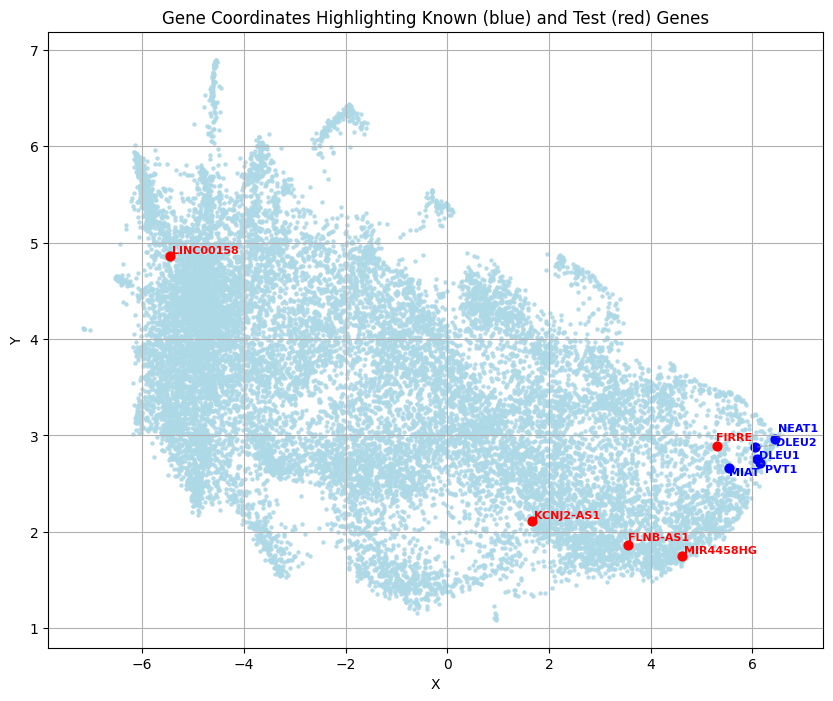

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# --- Prepare dataframe ---
df = df.rename(columns={"Unnamed: 0": "gene"})

# --- Gene sets ---
known_genes = ["DLEU1", "DLEU2", "MIAT", "NEAT1", "PVT1"]

test_genes = ["FIRRE", "MIR4458HG", "LINC00158", "KCNJ2-AS1", "FLNB-AS1"]

highlight_genes = known_genes + test_genes

# --- Basic scatter plot ---
plt.figure(figsize=(10, 8))
plt.scatter(df['x'], df['y'], color='lightblue', alpha=0.8, s=5)

texts = []

# --- Highlight known genes (blue) ---
for _, row in df.iterrows():
    if row['gene'] in known_genes:
        plt.scatter(row['x'], row['y'], color='blue', s=40)
        texts.append(plt.text(row['x'], row['y'], row['gene'], fontsize=8, fontweight='bold', color='blue'))

# --- Highlight test genes (red) ---
for _, row in df.iterrows():
    if row['gene'] in test_genes:
        plt.scatter(row['x'], row['y'], color='red', s=40)
        texts.append(plt.text(row['x'], row['y'], row['gene'], fontsize=8, fontweight='bold', color='red'))

# Automatically adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Gene Coordinates Highlighting Known (blue) and Test (red) Genes')
plt.grid(True)
plt.show()
